# 01 — Inspección de una corrida CORSIKA

Carga la salida de `sim/output/` y verifica:
1. Metadatos del run (versión, primario, energía, ángulos, OBSLEV).
2. Promedios de partículas al nivel de observación — **debe haber muones** si el primario es protón (PRMPAR=14).
3. Perfil longitudinal — gammas, electrones y muones por profundidad atmosférica.

**Setup local** (una sola vez):
```bash
sudo apt install python3-pandas python3-matplotlib jupyter-notebook
```
Luego `jupyter notebook` desde la raíz del repo.

In [8]:
import sys
from pathlib import Path

# Permite importar `analysis.corsika` corriendo el notebook desde notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis.corsika import CorsikaRun, PARTICLE_NAMES

In [17]:
run = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=1001)

print("lst :", run.lst_path)
print("long:", run.long_path)
print("dat :", run.dat_path)

lst : /home/jarjarbinks/muon-tomography/sim/output/fuego_test.lst
long: /home/jarjarbinks/muon-tomography/sim/output/DAT001001.long
dat : /home/jarjarbinks/muon-tomography/sim/output/DAT001001


## Metadatos del run

In [18]:
md = run.lst.metadata()
for k, v in md.__dict__.items():
    print(f"  {k:24s} = {v}")

  run_number               = 1001
  n_showers                = 500
  primary_id               = 14
  primary_name             = p
  energy_min_gev           = 10.0
  energy_max_gev           = 100000.0
  spectral_slope           = -2.7
  theta_min_deg            = 0.0
  theta_max_deg            = 89.0
  phi_min_deg              = 0.0
  phi_max_deg              = 360.0
  obslev_cm                = 200000.0
  obslev_gcm2              = 813.299992
  corsika_version          = 7.8050


**Sanity check:** `primary_name` debe decir `p` (protón). Si dice `gamma` entonces `PRMPAR` quedó en 1 — bug viejo, los steering files lo tenían así.

## Promedios de partículas al nivel de observación

In [19]:
avgs = run.lst.particle_averages()
avgs

,particle,mean,std
0,PROTONS,0.000,0.100000
1,ANTIPROTONS,0.000,0.000000
2,NEUTRONS,0.000,0.100000
3,ANTINEUTRONS,0.000,0.000000
4,GAMMAS,0.446,2.088014
5,POSITRONS,0.034,0.211976
6,ELECTRONS,0.066,0.392367
7,MU +,0.100,0.600000
8,MU -,0.100,0.300000
9,PI 0,0.000,0.000000


**Qué esperar (primario = protón, 10 GeV – 100 TeV, θ ∈ [0°, 89°], obslev = 2000 m):**
- `MU +` y `MU -` con mean > 0 (al menos ~1 por evento promediando 500 showers).
- `GAMMAS` y `ELECTRONS` dominantes (productos del cascadeo EM).
- Hadrones residuales (`PI +`, `PI -`, etc.) muy pocos a esta profundidad atmosférica.

Si todos los muones / hadrones son cero, probablemente el primario era gamma (bug viejo).

## Perfil longitudinal

Promedio sobre todos los showers de cada bin de profundidad.

In [20]:
long_df = run.long.particles()
print(f"showers = {long_df['shower'].nunique()}, bins de profundidad = {long_df['depth'].nunique()}")
long_df.head()

showers = 500, bins de profundidad = 41


,shower,depth,gammas,positrons,electrons,mu+,mu-,hadrons,charged,nuclei,cherenkov
0,1,20.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1,40.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1,60.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1,80.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1,100.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [21]:
# Promedio por bin de profundidad (a través de los 500 showers)
profile = long_df.groupby("depth")[
    ["gammas", "positrons", "electrons", "mu+", "mu-", "hadrons", "charged"]
].mean()
profile.head()

,gammas,positrons,electrons,mu+,mu-,hadrons,charged
depth,,,,,,,
20.0,3.224,0.576,0.758,0.178,0.170,1.260,2.672
40.0,9.400,1.382,1.984,0.324,0.284,1.520,4.950
60.0,15.536,2.130,2.932,0.462,0.358,1.570,6.768
80.0,20.410,2.518,3.474,0.472,0.380,1.628,7.698
100.0,23.976,2.688,3.818,0.478,0.394,1.590,8.200


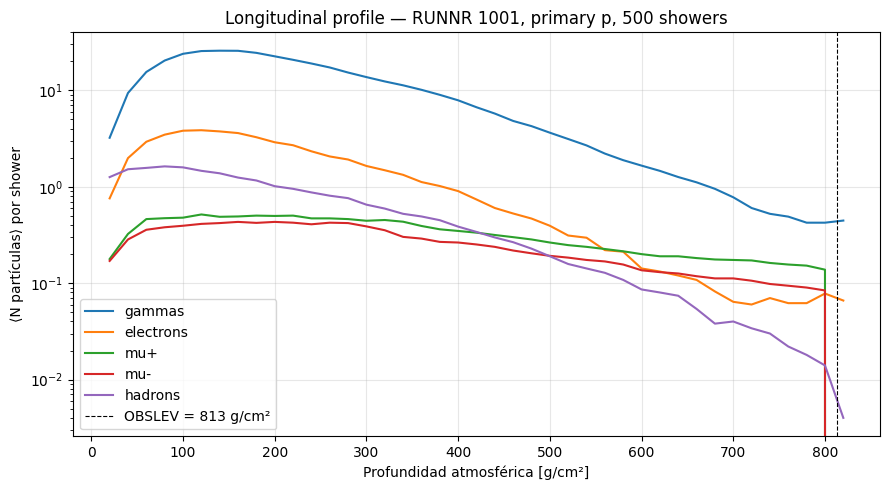

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ("gammas", "tab:blue"),
    ("electrons", "tab:orange"),
    ("mu+", "tab:green"),
    ("mu-", "tab:red"),
    ("hadrons", "tab:purple"),
]:
    ax.plot(profile.index, profile[col], label=col, color=color, lw=1.5)

ax.set_xlabel("Profundidad atmosférica [g/cm²]")
ax.set_ylabel("⟨N partículas⟩ por shower")
ax.set_title(f"Longitudinal profile — RUNNR {md.run_number}, primary {md.primary_name}, {md.n_showers} showers")
ax.set_yscale("log")
ax.axvline(md.obslev_gcm2, color="k", ls="--", lw=0.8, label=f"OBSLEV = {md.obslev_gcm2:.0f} g/cm²")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura esperada (primario = protón):**
- Gammas y electrones siguen la curva de Heitler-Greisen, con máximo cerca de 300–400 g/cm² para E ≈ 10–100 GeV.
- Muones aparecen pronto (~200 g/cm²) y decaen lentamente — son penetrantes, llegan al OBSLEV.
- En OBSLEV (línea vertical) ⟨N⟩ refleja lo que el detector vería en superficie.

## Siguiente paso

Cuando el output binario (`DAT001001`) sea relevante para muografía:

```python
# Requiere `corsika-panama` (ya está en thesis-corsika)
from corsikaio import CorsikaParticleFile

with CorsikaParticleFile(run.dat_path) as f:
    for event in f:
        particles = event.particles  # numpy structured array
        muons = particles[(particles['particle_id'] == 5) | (particles['particle_id'] == 6)]
        ...
```